In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:16<00:00, 20.8MB/s]



In [ ]:
import zipfile
zip = zipfile.ZipFile("/content/utkface-new.zip",'r')
zip.extractall("/content")
zip.close()

In [ ]:
import os
import numpy as np
import pandas as pd
#from keras.src.preprocessing.image import ImageDataGenerator

In [ ]:
folder_path = '/content/utkface_aligned_cropped/UTKFace'

In [ ]:
age=[]
gender=[]
img_path=[]
for file in os.listdir(folder_path):
  age.append(int(file.split('_')[0]))
  gender.append(int(file.split('_')[1]))
  img_path.append(file)

In [ ]:
len(age)

23708

In [ ]:
df = pd.DataFrame({'age':age,'gender':gender,'img':img_path})

In [ ]:
df.shape

(23708, 3)

In [ ]:
df.head()

,age,gender,img
0,3,0,3_0_1_20170110213455106.jpg.chip.jpg
1,1,0,1_0_3_20161219224546584.jpg.chip.jpg
2,24,0,24_0_0_20170105184142103.jpg.chip.jpg
3,45,0,45_0_0_20170117183552230.jpg.chip.jpg
4,18,1,18_1_2_20170102234846172.jpg.chip.jpg


In [ ]:
train_df = df.sample(frac=1,random_state=0).iloc[:20000]
test_df = df.sample(frac=1,random_state=0).iloc[20000:]

In [ ]:
train_df.shape

(20000, 3)

In [ ]:
test_df.shape

(3708, 3)

In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

In [ ]:
train_datagen = tf.keras.Sequential([
     # Geometric shifts
    layers.Rescaling(1./255),
    layers.RandomFlip(mode="horizontal"),
    layers.RandomRotation(factor=30/360),
    layers.RandomZoom(height_factor=(-0.2, 0.2)),
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    layers.RandomShear(x_factor=0.2, y_factor=0.2)


])

test_datagen = tf.keras.Sequential([
    layers.Rescaling(1./255)
])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   age     23708 non-null  int64 
 1   gender  23708 non-null  int64 
 2   img     23708 non-null  object
dtypes: int64(2), object(1)
memory usage: 555.8+ KB


In [ ]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    directory=folder_path,
                                                    x_col='img',
                                                    y_col=['age','gender'],
                                                    target_size=(200,200),
                                                    class_mode='multi_output')

test_generator = test_datagen.flow_from_dataframe(test_df,
                                                    directory=folder_path,
                                                    x_col='img',
                                                    y_col=['age','gender'],
                                                    target_size=(200,200),
                                                  class_mode='multi_output')

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [ ]:
from keras.applications.resnet50 import ResNet50
from keras.layers import *
from keras.models import Model

In [ ]:
model.fit(train_generator, batch_size=32, epochs=10, validation_data=test_generator)

Epoch 1/10
625/625 [==============================] - 192s 308ms/step - loss: 99.9177 - age_loss: 15.4168 - gender_loss: 0.8535 - age_mae: 15.4168 - gender_accuracy: 0.5128 - val_loss: 83.2029 - val_age_loss: 14.7048 - val_gender_loss: 0.6919 - val_age_mae: 14.7048 - val_gender_accuracy: 0.5251
Epoch 2/10
625/625 [==============================] - 189s 302ms/step - loss: 83.7399 - age_loss: 15.1015 - gender_loss: 0.6933 - age_mae: 15.1015 - gender_accuracy: 0.5214 - val_loss: 144.5108 - val_age_loss: 14.6180 - val_gender_loss: 1.3120 - val_age_mae: 14.6180 - val_gender_accuracy: 0.5251
Epoch 3/10
625/625 [==============================] - 187s 299ms/step - loss: 84.2922 - age_loss: 14.9594 - gender_loss: 0.7003 - age_mae: 14.9594 - gender_accuracy: 0.5206 - val_loss: 83.4230 - val_age_loss: 14.9192 - val_gender_loss: 0.6920 - val_age_mae: 14.9192 - val_gender_accuracy: 0.5251
Epoch 4/10
625/625 [==============================] - 185s 296ms/step - loss: 83.5334 - age_loss: 14.8921 - gen

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import pandas as pd
import numpy as np

# ==========================================
# 0. CONFIGURATION & PREPARATIONS
# ==========================================
# Change these to match your actual environment setup

IMG_HEIGHT = 200
IMG_WIDTH = 200
BATCH_SIZE = 32

# (Assuming your train_df and test_df are already defined above this line)

# ==========================================
# 1. DEFINE DATA LOADING FUNCTIONS
# ==========================================
def load_and_preprocess(file_name, age, gender):
    # Combine folder path with file name to get full path
    full_path = tf.strings.join([folder_path, "/", file_name])

    # Read, decode, and resize the raw image data
    image = tf.io.read_file(full_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])

    # Return image and target dictionary matching the model output names
    return image, {"age": age, "gender": gender}

# ==========================================
# 2. CREATE FAST PIPELINES (Replaces flow_from_dataframe)
# ==========================================
# Training Pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((
    train_df['img'].values.astype(str),
    train_df['age'].values.astype(np.float32),
    train_df['gender'].values.astype(np.float32)
))
train_loader = (train_dataset
                .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                .shuffle(buffer_size=1000)
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))

# Testing Pipeline
test_dataset = tf.data.Dataset.from_tensor_slices((
    test_df['img'].values.astype(str),
    test_df['age'].values.astype(np.float32),
    test_df['gender'].values.astype(np.float32)
))
test_loader = (test_dataset
               .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

In [ ]:
input_layer = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Embedded Augmentation & Rescaling (Replaces ImageDataGenerator parameters)
x = layers.Rescaling(1./255)(input_layer)
x = layers.RandomRotation(factor=30/360)(x)
x = layers.RandomTranslation(height_factor=0.2, width_factor=0.2)(x)
x = layers.RandomShear(x_factor=0.2, y_factor=0.2)(x)
x = layers.RandomZoom(height_factor=0.2, width_factor=0.2)(x)
x = layers.RandomFlip(mode="horizontal")(x)

In [ ]:
resnet = ResNet50(include_top=False, input_shape=(200, 200, 3))
resnet.trainable = False

# 4. Pass our augmented images (x) into the ResNet model
resnet_output = resnet(x)

flatten = Flatten()(resnet_output)

dense1 = Dense(512, activation='relu')(flatten)
dense2 = Dense(512,activation='relu')(flatten)

dense3 = Dense(512,activation='relu')(dense1)
dense4 = Dense(512,activation='relu')(dense2)

output1 = Dense(1,activation='linear',name='age')(dense3)
output2 = Dense(1,activation='sigmoid',name='gender')(dense4)

model = Model(inputs=input_layer,outputs=[output1,output2])

model.compile(
    optimizer='adam',
    loss={
        'age': 'mse',
        'gender': 'binary_crossentropy'
    },
    metrics={
        'age': 'mae',
        'gender': 'accuracy'
    }
)

In [ ]:
# Start training
history = model.fit(
    train_loader,
    validation_data=test_loader,
    epochs=10
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 204ms/step - age_loss: 411.0093 - age_mae: 15.6795 - gender_accuracy: 0.5088 - gender_loss: 0.8706 - loss: 411.8798 - val_age_loss: 380.3342 - val_age_mae: 14.7869 - val_gender_accuracy: 0.5210 - val_gender_loss: 0.6924 - val_loss: 381.0184
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 199ms/step - age_loss: 399.4260 - age_mae: 15.4456 - gender_accuracy: 0.5224 - gender_loss: 0.6976 - loss: 400.1235 - val_age_loss: 376.0384 - val_age_mae: 14.8484 - val_gender_accuracy: 0.5210 - val_gender_loss: 0.6924 - val_loss: 376.7242
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 124s 198ms/step - age_loss: 392.2750 - age_mae: 15.3219 - gender_accuracy: 0.5229 - gender_loss: 0.6924 - loss: 392.9674 - val_age_loss: 368.5074 - val_age_mae: 14.3732 - val_gender_accuracy: 0.5210 - val_gender_loss: 0.6924 - val_loss: 369.1940
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 200ms/step - age_loss: 384.2633 - age_mae: 15.1553 - gender_accuracy: 0.5232 - gender_loss: 0.694

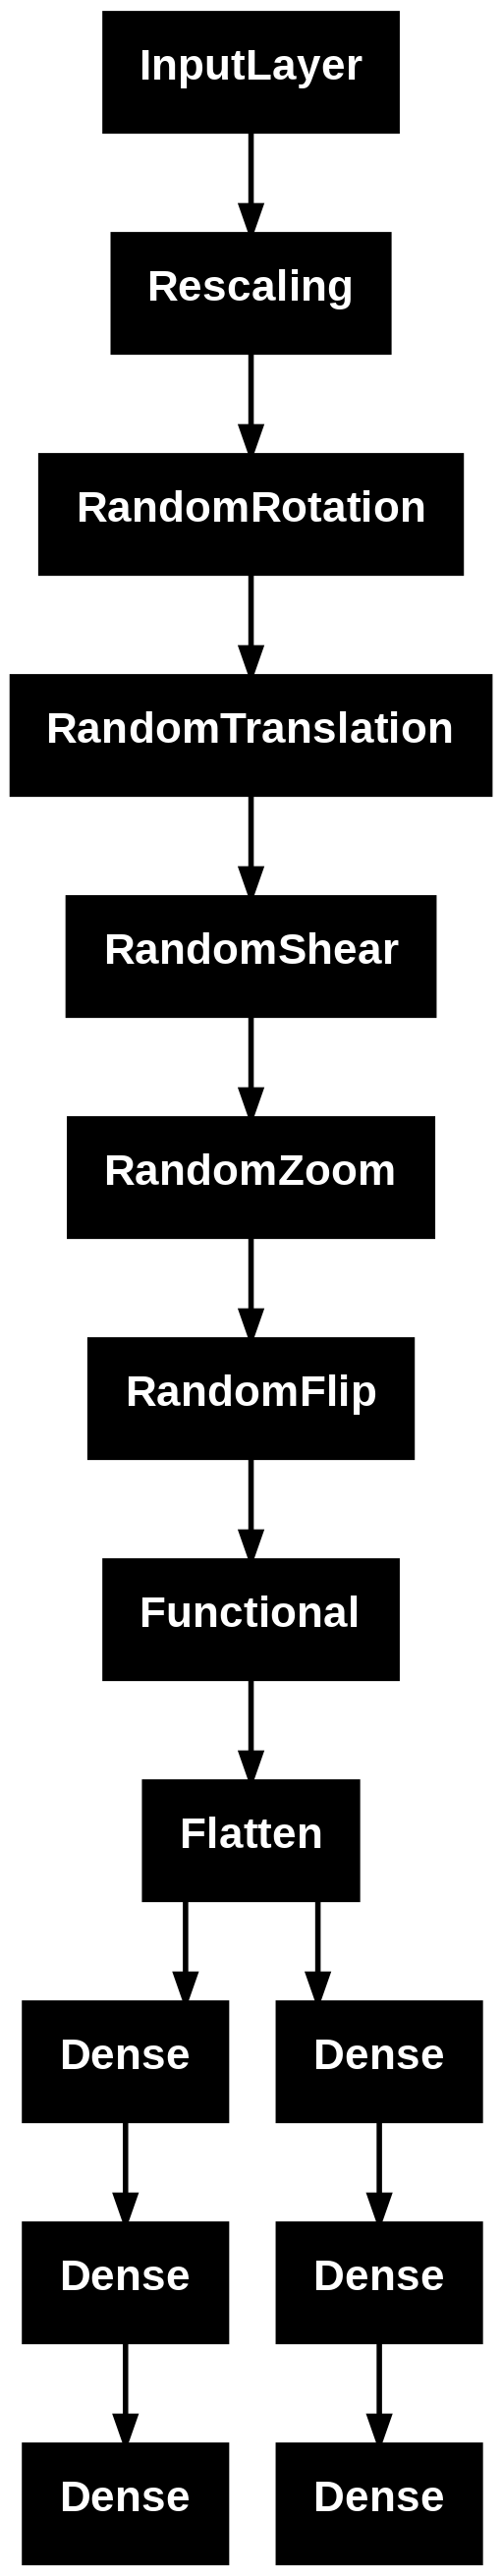

In [ ]:
from keras.utils import plot_model

plot_model(model)